# ECH paper predictor - single case

This notebook mirrors `run_single_case.py`, but runs `ML_predictor_Paper.py`. The model uses all 10 ECH technical indicators from Table 5 and does not rank or select features with Pearson correlation.

In [2]:
from pathlib import Path
import sys

# Make imports work whether Jupyter starts in the repository root or this notebook's folder.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").is_dir():
    repo_root = repo_root.parent
if not (repo_root / "src").is_dir():
    raise RuntimeError("Could not locate the Bluegrey repository root.")

predictor_dir = repo_root / "research" / "Mateo" / "ML_predictor"
for path in (repo_root, predictor_dir):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from ML_predictor_Paper import ECH_TECHNICAL_INDICATORS, MLPredictorStrategy
from src.vector_backtester_Mateo import PortfolioVectorEngine

ECH_TECHNICAL_INDICATORS

('AOBV_LR_2',
 'BBP_5_2.0',
 'BOP',
 'CTI_12',
 'DEC_1',
 'EBSW_40_10',
 'INC_1',
 'J_9_3',
 'K_9_3',
 'ZS_30')

In [3]:
def run_single_case_paper(
    symbol,
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.002,
    training_years=10,
    indicator_warmup_years=1,
    position_size=1.0,
    initial_capital=1_000_000,
    max_iter=5000,
    execution_delay=1,
    download_data=False,
    adj_method="corporate_actions",
    verbose=False,
    show_progress=True,
):
    """Prepare data, generate walk-forward signals, and backtest one paper-predictor case."""
    if asset_class not in {"STK", "CRYPTO", "FX"}:
        raise ValueError('asset_class must be "STK", "CRYPTO", or "FX".')

    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "training_years": training_years,
        "indicator_warmup_years": indicator_warmup_years,
        "position_size": position_size,
        "max_iter": max_iter,
        "download_data": download_data,
        "adj_method": adj_method,
        "verbose": verbose,
    }

    strategy = MLPredictorStrategy(params=params)
    dataset = strategy.prepare_dataset()

    model_features, _ = strategy.feature_target_split_dataset(dataset)
    if tuple(model_features.columns) != ECH_TECHNICAL_INDICATORS:
        raise RuntimeError("The model feature matrix does not match the paper's ECH indicators.")
    print(f"Using {model_features.shape[1]} model features: {model_features.columns.tolist()}")

    weights = strategy.generate_signals(dataset, show_progress=show_progress)
    if weights.empty:
        print("No weights were generated; the backtest was not run.")
        return None

    prices = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=asset_class,
        initial_capital=initial_capital,
        execution_delay=execution_delay,
    )
    engine.run()
    engine.tearsheet(f"{symbol} ML Walk Forward - Paper Indicators")

    return {
        "params": params,
        "strategy": strategy,
        "dataset": dataset,
        "weights": weights,
        "prices": prices,
        "engine": engine,
    }

## Run ECH

The default uses the stored Yahoo CSV. Set `download_data=True` in the call if you want to refresh it from Yahoo Finance.

Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.46s |  elapsed: 1m 18.6s250 |  last: 0.20s |  elapsed: 13.9s 245/250 |  last: 0.20s |  elapsed: 1m 16.9s
✅ Prediction complete. Took 1m 18.8s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     12.19%
   Net Strategy Return:     6.85%  (EW Benchmark: 65.17%)
   Max Drawdown:            -18.29%
   Win Rate (Gross Bars):   51.4%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  45.8%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  2.8%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      0.40    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        0.41    (EW Benchmark: 2.67)
   Total Fees Paid:         $53,413.80
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegr

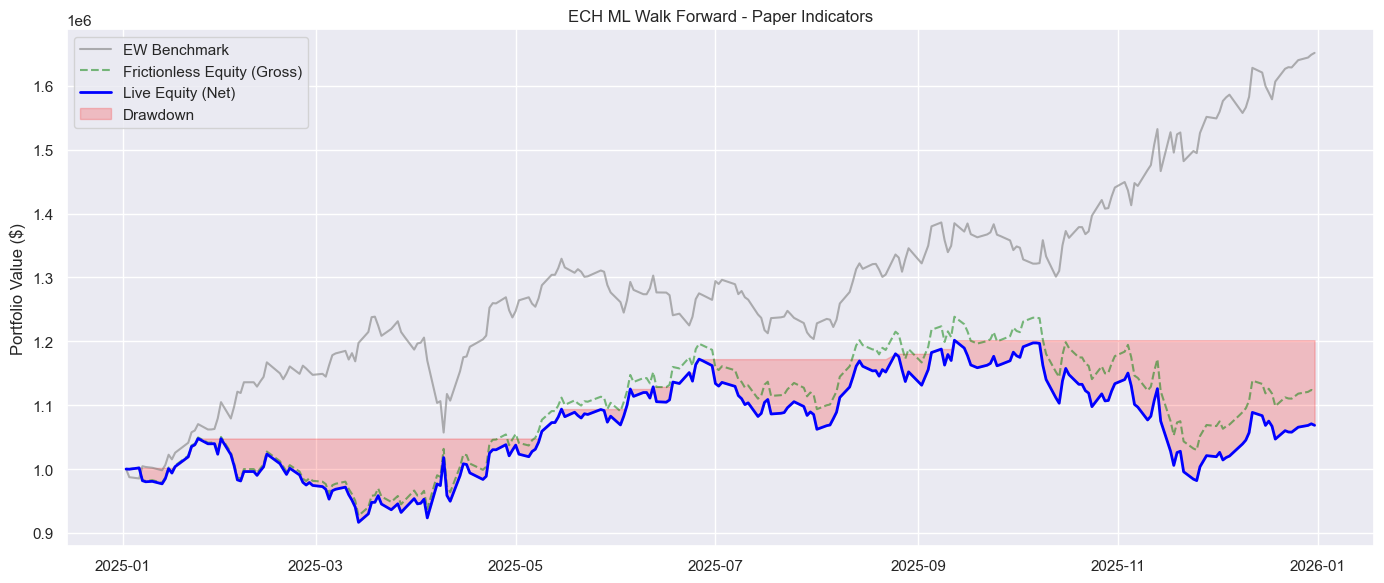

In [5]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.0,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.27s |  elapsed: 1m 14.1s250 |  last: 0.20s |  elapsed: 24.5s 91/250 |  last: 0.20s |  elapsed: 26.2s
✅ Prediction complete. Took 1m 14.3s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     18.71%
   Net Strategy Return:     13.63%  (EW Benchmark: 65.17%)
   Max Drawdown:            -20.74%
   Win Rate (Gross Bars):   53.8%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  43.4%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  2.8%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      0.67    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        0.68    (EW Benchmark: 2.67)
   Total Fees Paid:         $50,714.47
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/

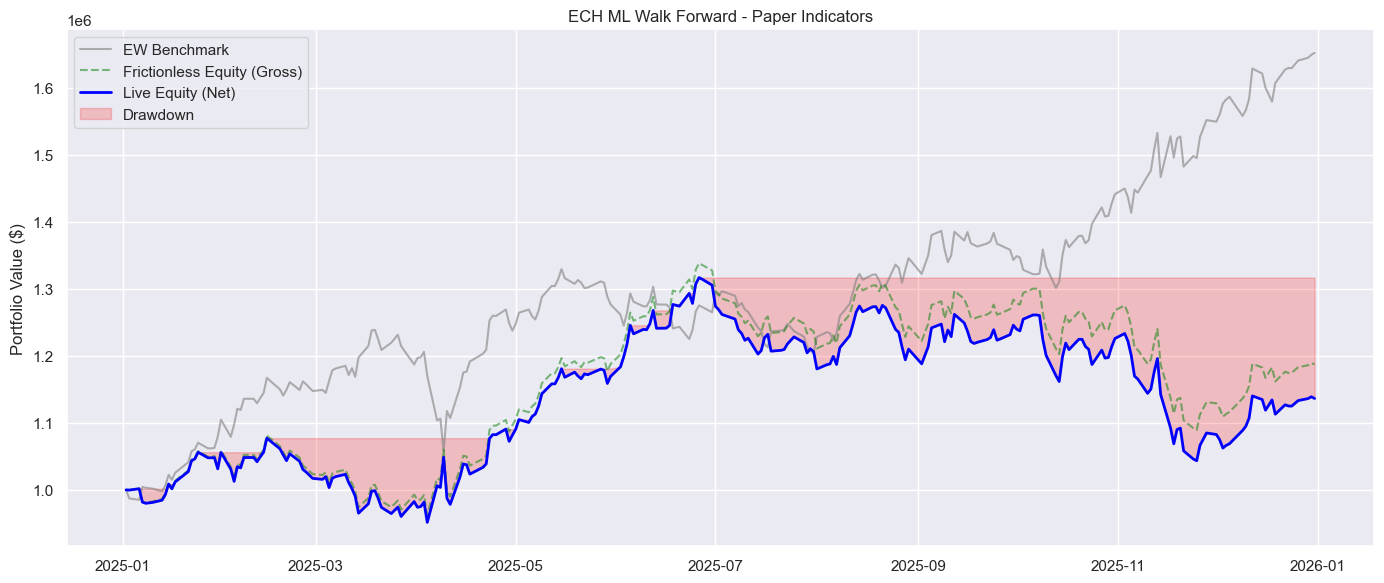

In [6]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.001,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.41s |  elapsed: 1m 31.8s250 |  last: 0.20s |  elapsed: 23.7s 99/250 |  last: 0.20s |  elapsed: 35.9s 200/250 |  last: 0.20s |  elapsed: 1m 14.1s
✅ Prediction complete. Took 1m 32.0s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     26.40%
   Net Strategy Return:     21.18%  (EW Benchmark: 65.17%)
   Max Drawdown:            -18.56%
   Win Rate (Gross Bars):   55.8%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  41.4%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  2.8%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      0.96    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        0.98    (EW Benchmark: 2.67)
   Total Fees Paid:         $52,220.03
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet s

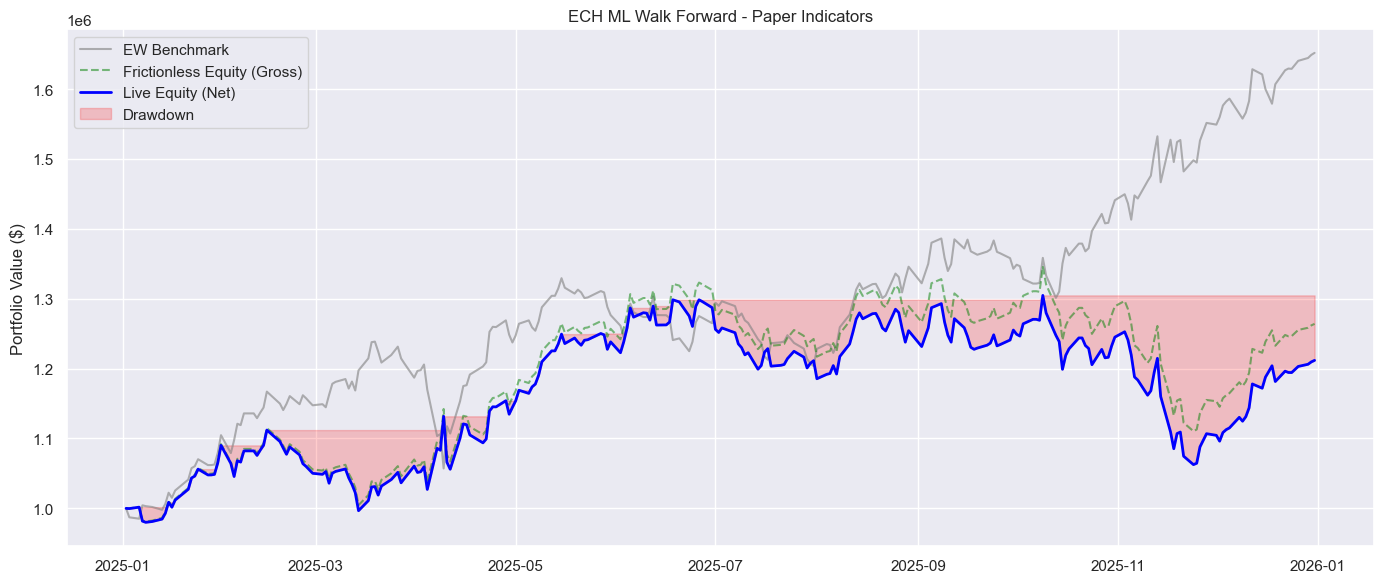

In [3]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.002,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.47s |  elapsed: 1m 47.0s
✅ Prediction complete. Took 1m 47.2s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     42.40%
   Net Strategy Return:     37.42%  (EW Benchmark: 65.17%)
   Max Drawdown:            -13.21%
   Win Rate (Gross Bars):   55.0%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  42.2%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  2.8%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      1.51    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        1.63    (EW Benchmark: 2.67)
   Total Fees Paid:         $49,812.94
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_-_Paper_Indicators_tearsheet.html
  

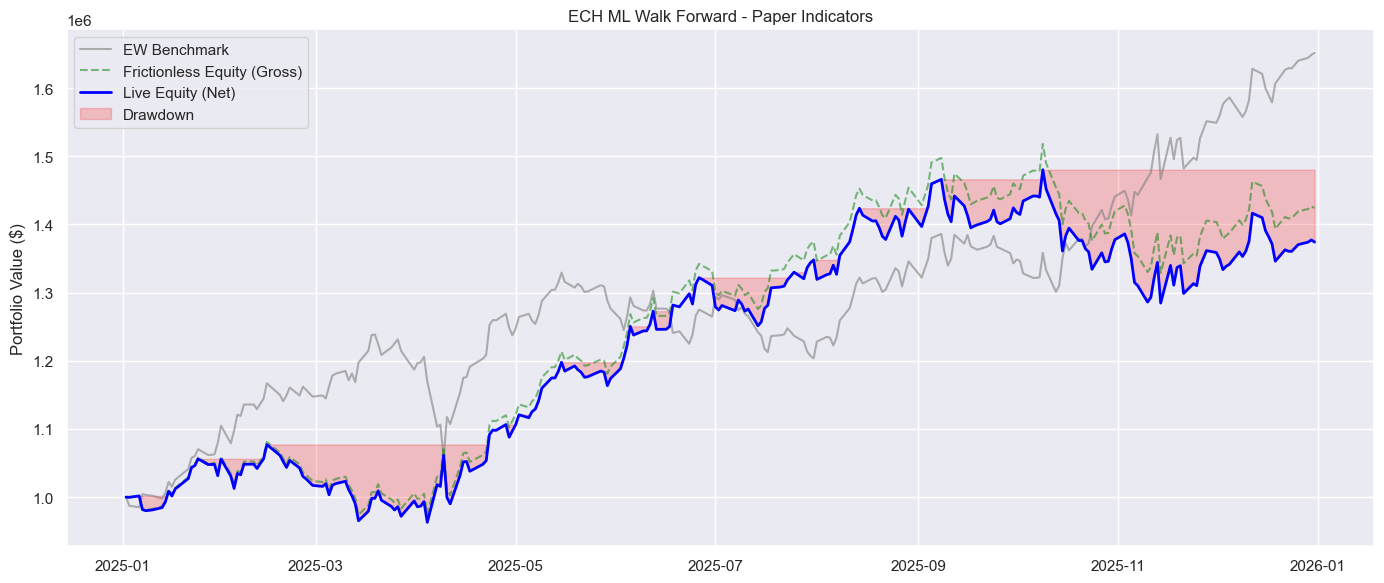

In [7]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.003,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.47s |  elapsed: 2m 4.8ss
✅ Prediction complete. Took 2m 5.0s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     41.16%
   Net Strategy Return:     35.29%  (EW Benchmark: 65.17%)
   Max Drawdown:            -13.18%
   Win Rate (Gross Bars):   54.2%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  40.6%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  5.2%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      1.46    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        1.56    (EW Benchmark: 2.67)
   Total Fees Paid:         $58,639.68
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_-_Paper_Indicators_tearsheet.html
   

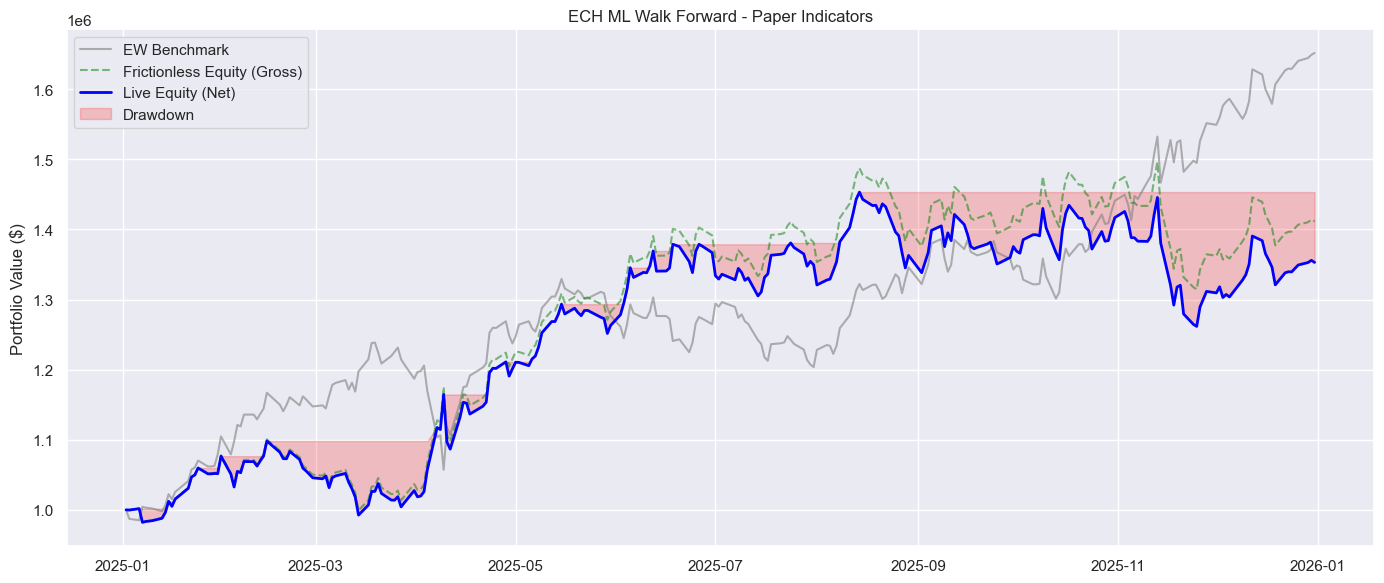

In [8]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.004,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.38s |  elapsed: 2m 6.2ss
✅ Prediction complete. Took 2m 6.5s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     20.79%
   Net Strategy Return:     15.61%  (EW Benchmark: 65.17%)
   Max Drawdown:            -11.18%
   Win Rate (Gross Bars):   45.8%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  39.0%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  15.3%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      0.80    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        0.84    (EW Benchmark: 2.67)
   Total Fees Paid:         $51,822.80
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_-_Paper_Indicators_tearsheet.html
  

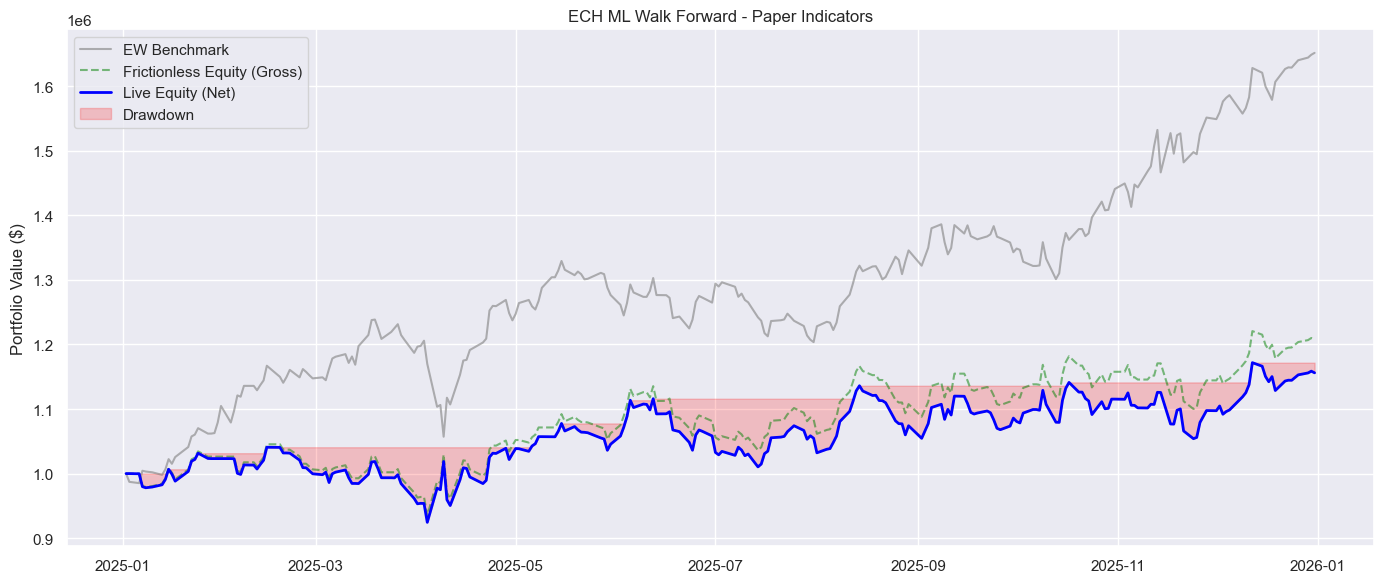

In [9]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.005,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

The case `signal_threshold=0.003` is the best for the paper's 10-feature set.

I want to compare to the best case with my feature-selection process:
`signal_threshold=0.003` and `n_festures=16` chosen via top Pearson correlation.

🧠 Predicting 2025-12-31 |  250/250 |  last: 0.34s |  elapsed: 2m 2.4ss
✅ Prediction complete. Took 2m 2.9s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     60.58%
   Net Strategy Return:     54.76%  (EW Benchmark: 65.17%)
   Max Drawdown:            -11.31%
   Win Rate (Gross Bars):   53.8%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  42.2%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  4.0%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      2.05    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        2.31    (EW Benchmark: 2.67)
   Total Fees Paid:         $58,201.36
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


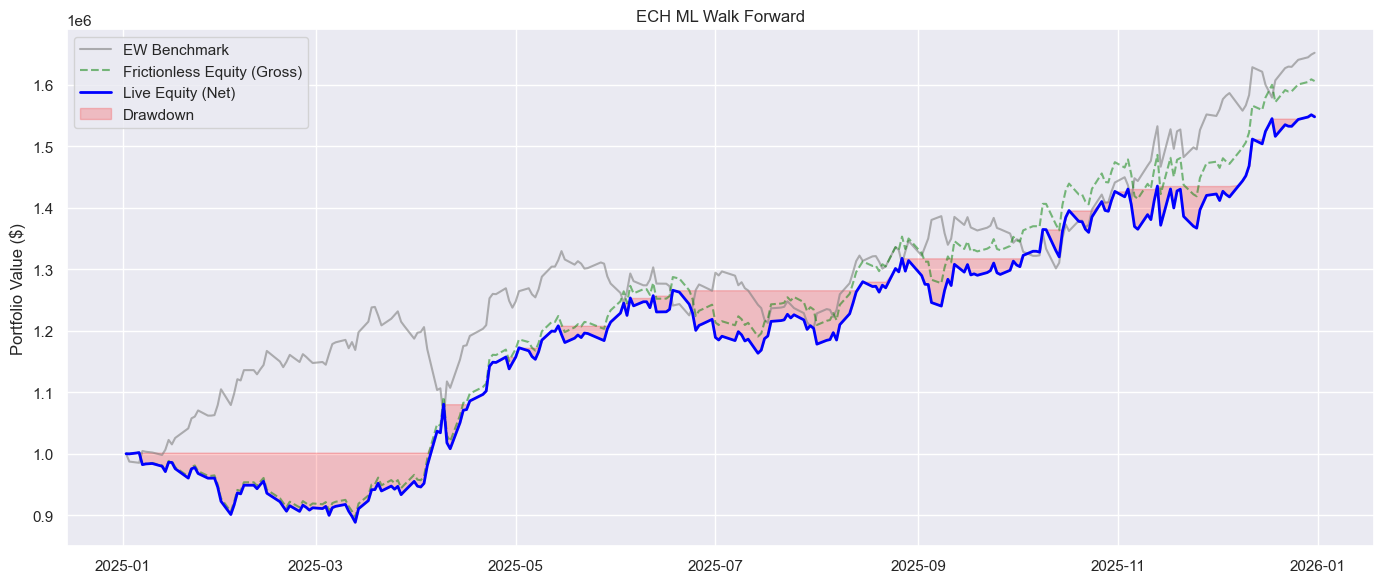

In [ ]:
from run_single_case import run_single_case

run_single_case(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    n_features=16,
    signal_threshold=0.003,
    training_years=10,
    show_progress=True,
)

🧠 Predicting 2025-12-31 |  250/250 |  last: 0.15s |  elapsed: 1m 12.3s250 |  last: 0.20s |  elapsed: 24.8s
✅ Prediction complete. Took 1m 12.5s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     15.69%
   Net Strategy Return:     11.29%  (EW Benchmark: 65.17%)
   Max Drawdown:            -22.51%
   Win Rate (Gross Bars):   51.4%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  45.8%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  2.8%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      0.58    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        0.56    (EW Benchmark: 2.67)
   Total Fees Paid:         $44,018.23
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


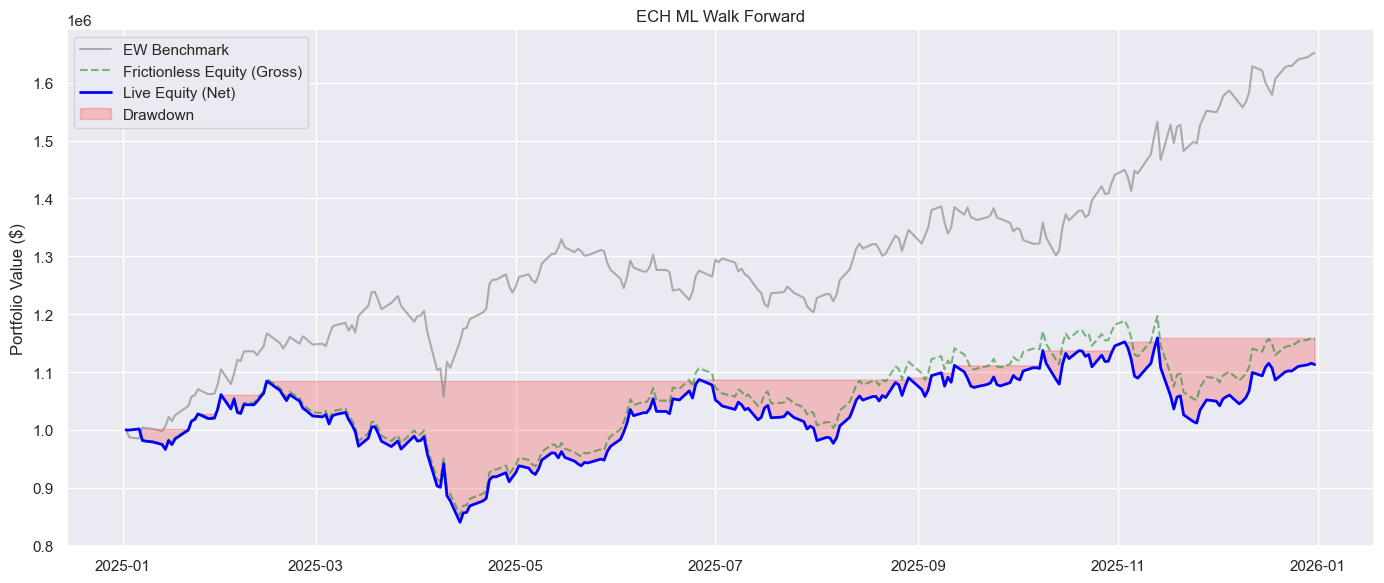

In [5]:
from run_single_case import run_single_case

run_single_case(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    n_features=10,
    signal_threshold=0.003,
    training_years=10,
    show_progress=True,
)

My top Pearson-correlation predictor does better (far better) than the top Paper-set, but it's not really fair that I get to choose my top performer a posteriori. To be fair, the paper's 10 features do better than my predictor with features=10.

How would have they performed over a longer period?


Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2025-12-31 |  752/752 |  last: 0.09s |  elapsed: 1m 11.1s1/752 |  last: 0.06s |  elapsed: 46.2s 576/752 |  last: 0.08s |  elapsed: 53.0s 581/752 |  last: 0.08s |  elapsed: 53.3s 665/752 |  last: 0.10s |  elapsed: 1m 1.6s
✅ Prediction complete. Took 1m 11.1s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     55.42%
   Net Strategy Return:     37.21%  (EW Benchmark: 66.10%)
   Max Drawdown:            -30.35%
   Win Rate (Gross Bars):   51.4%   (EW Benchmark: 51.1%)
   Loss Rate (Gross Bars):  47.4%   (EW Benchmark: 47.8%)
   Zero Rate (Gross Bars):  1.2%    (EW Benchmark: 1.1%)
   Sharpe Ratio (Net):      0.56    (EW Benchmark: 0.87)
   Sortino/√2 (Net):        0.58    (EW Benchmark: 0.89)
   Total Fees Paid:         $182,081.22
---------------------------------------------
📈 Generating Instituti

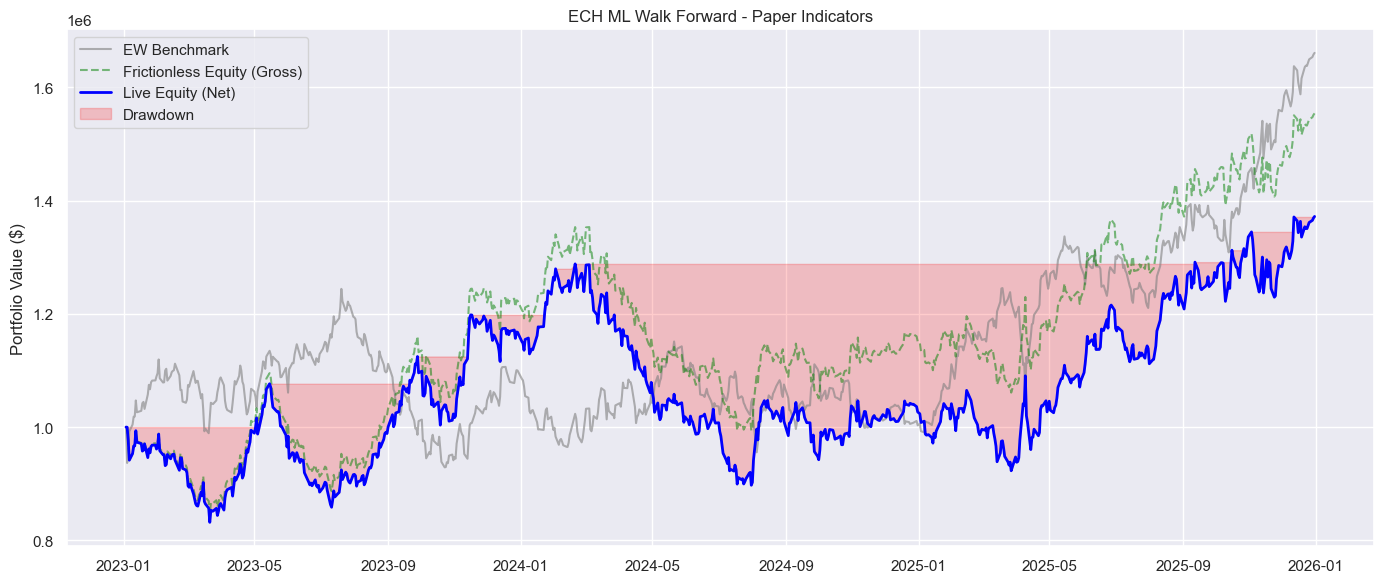

In [4]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2023-01-01",
    end_date="2026-01-01",
    signal_threshold=0.003,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

The paper's perdictor's accuracy is 51.4% over the longer 2023-2025 year span, nowhere near the quoted ~80% in the paper. It is clear that the paper is strongly flawed (as we already knew). The signal assignmnet is wrong for starters, and the k-cross validation isn't appropriate for a time series.

🧠 Predicting 2025-12-31 |  752/752 |  last: 0.33s |  elapsed: 5m 55.1s
✅ Prediction complete. Took 5m 55.7s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     138.24%
   Net Strategy Return:     116.55%  (EW Benchmark: 66.10%)
   Max Drawdown:            -21.91%
   Win Rate (Gross Bars):   52.9%   (EW Benchmark: 51.1%)
   Loss Rate (Gross Bars):  45.0%   (EW Benchmark: 47.8%)
   Zero Rate (Gross Bars):  2.1%    (EW Benchmark: 1.1%)
   Sharpe Ratio (Net):      1.21    (EW Benchmark: 0.87)
   Sortino/√2 (Net):        1.29    (EW Benchmark: 0.89)
   Total Fees Paid:         $216,966.79
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


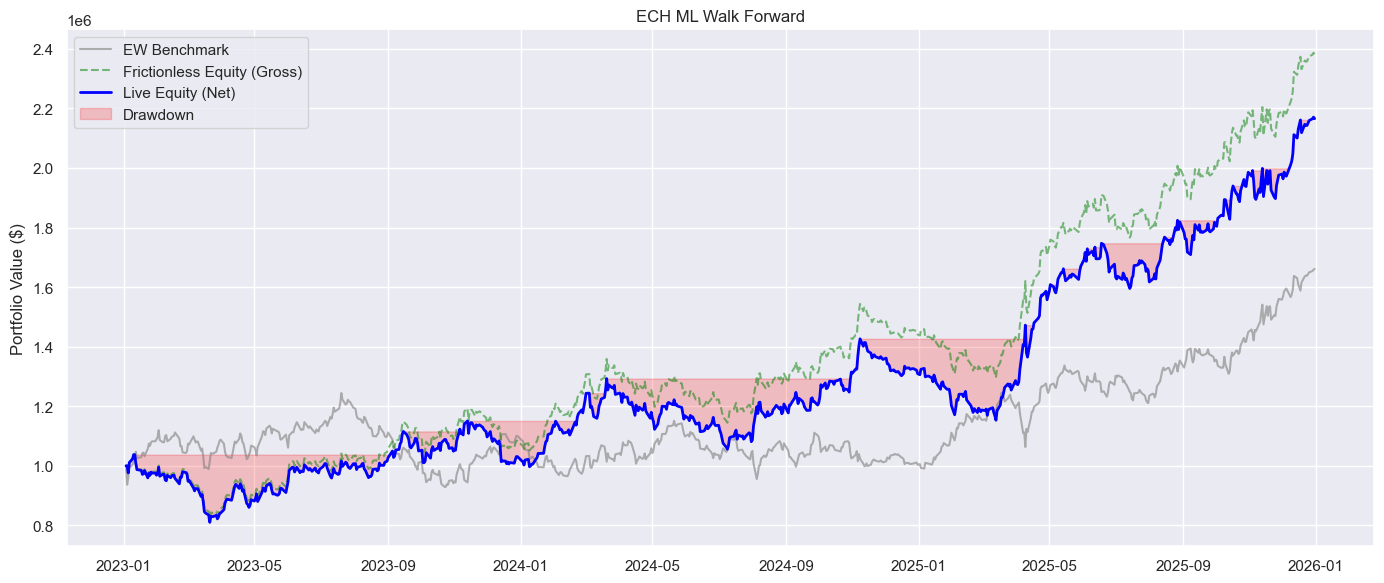

In [ ]:
from run_single_case import run_single_case

run_single_case(
    symbol="ECH",
    asset_class="STK",
    start_date="2023-01-01",
    end_date="2026-01-01",
    n_features=16,
    signal_threshold=0.003,
    training_years=10,
    show_progress=True,
)

Again, my top predictor does better in all metrics over the longer period


How about in the `2026-YTD` period?

Using 10 model features: ['AOBV_LR_2', 'BBP_5_2.0', 'BOP', 'CTI_12', 'DEC_1', 'EBSW_40_10', 'INC_1', 'J_9_3', 'K_9_3', 'ZS_30']
🧠 Predicting 2026-06-30 |  123/123 |  last: 0.14s |  elapsed: 14.1s
✅ Prediction complete. Took 14.3s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward - Paper Indicators ---
   Frictionless Return:     49.11%
   Net Strategy Return:     46.43%  (EW Benchmark: -1.03%)
   Max Drawdown:            -19.27%
   Win Rate (Gross Bars):   54.1%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  45.1%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  0.8%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      2.39    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        2.88    (EW Benchmark: 0.12)
   Total Fees Paid:         $26,772.41
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_-_Paper_Indicators_tearsheet.html
   (Open

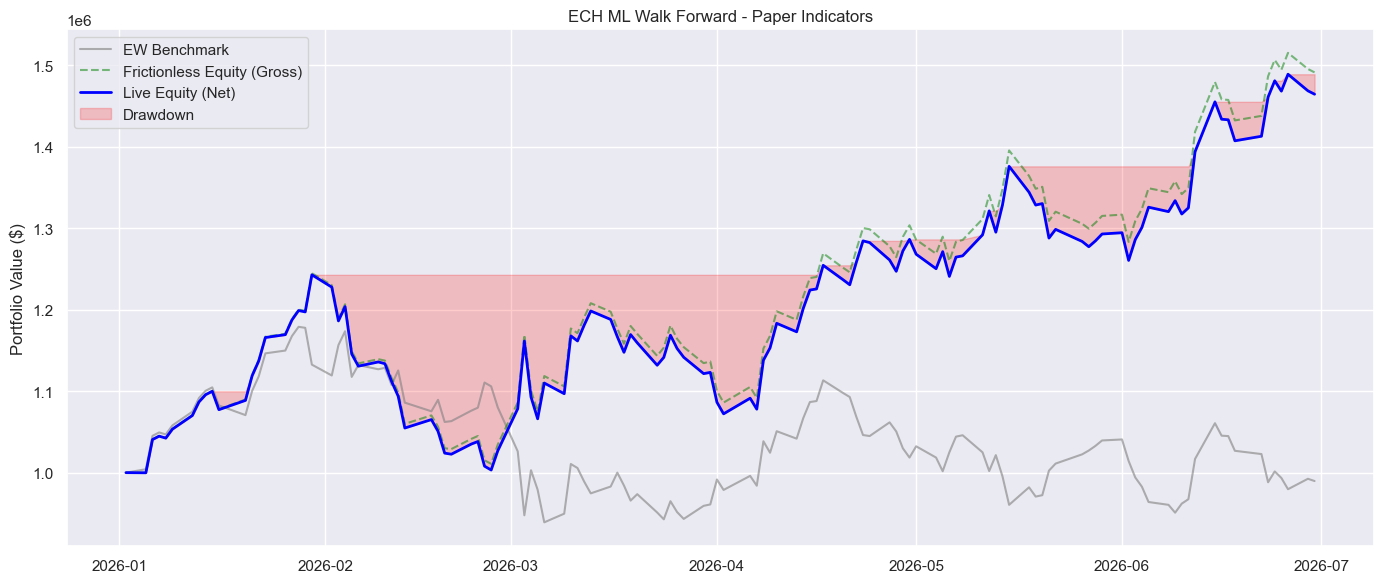

In [7]:
results = run_single_case_paper(
    symbol="ECH",
    asset_class="STK",
    start_date="2026-01-01",
    end_date="2026-07-01",
    signal_threshold=0.003,
    training_years=10,
    max_iter=5000,
    show_progress=True,
)

🧠 Predicting 2026-06-30 |  123/123 |  last: 0.60s |  elapsed: 55.7s
✅ Prediction complete. Took 56.3s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     -2.03%
   Net Strategy Return:     -3.93%  (EW Benchmark: -1.03%)
   Max Drawdown:            -33.23%
   Win Rate (Gross Bars):   46.7%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  52.5%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  0.8%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      -0.05    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        -0.06    (EW Benchmark: 0.12)
   Total Fees Paid:         $19,043.59
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


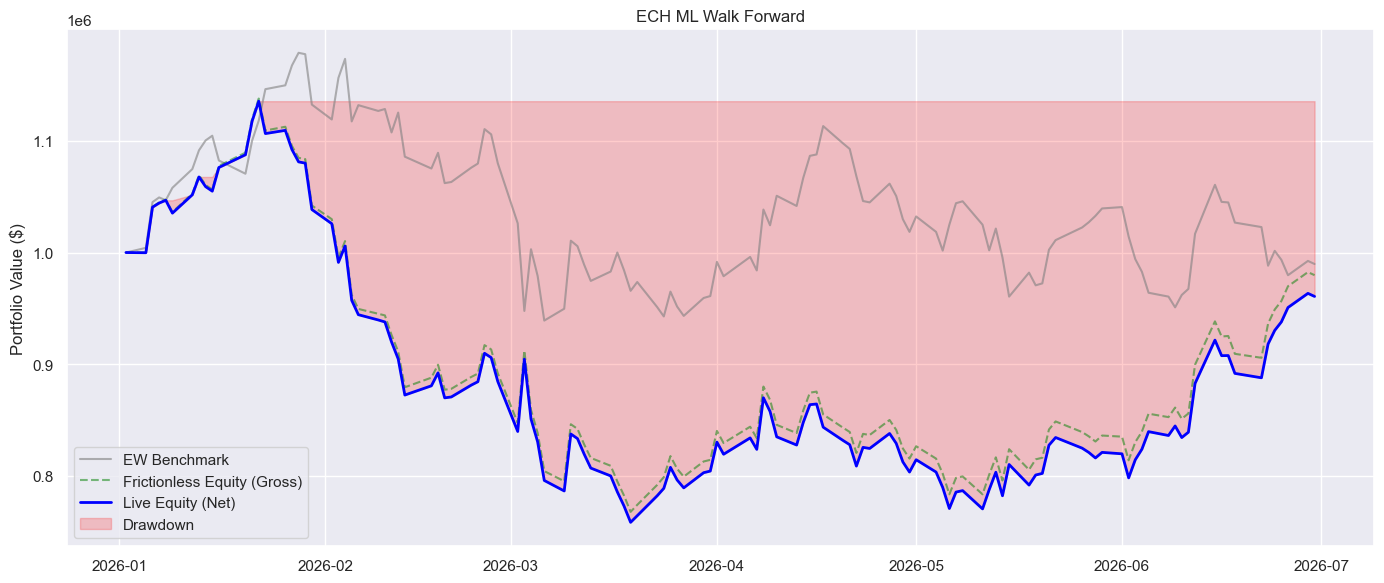

In [8]:
run_single_case(
    symbol="ECH",
    asset_class="STK",
    start_date="2026-01-01",
    end_date="2026-07-01",
    n_features=16,
    signal_threshold=0.003,
    training_years=10,
    show_progress=True,
)

Wow, instead, in `2026-YTD` the paper's 10-feaures perform outstandingly, while my top performer does bad, mostly due to a large -33% DD